## Great, now that we discussed a little let's continue

Given that the current approach utilized by the authors lacks reproducibility, we will explore an alternative method by leveraging nf-core pipelines for data analysis.

#### Please explain, how we will achieve reproducibility for the course  with this approach.


- Pinned pipeline version: -r 3.27.0
- Containers: -profile docker runs every tool from a fixed container image with fixed tool versions
- Pinned inputs: The raw data comes by SRA accession through fetchngs and the reference is a fixed Ensembl release (116, GRCm39)
- Everything is logged: pipeline_info/ records the parameters used, all software versions and execution reports
- Community standards -> same tools: nf-core pipelines are peer reviewed, CI tested on every change and documented
- Contrast with the paper: "HISAT2, HT-Seq and DESeq2" with no versions, parameters or genome build given

You have successfully downloaded 2 of the fastq files we will use in our study.

#### What is the next step if we want to first have a count table and check the quality of our fastq files? What is the pipeline called to do so?

**nf-core/rnaseq**

Input: FASTQs\
Output: QC, trimming and alignment and produces gene-level count matrices plus a MultiQC report

Analyze the 2 files using an nf-core pipeline.

#### What does this pipeline do? Which are the main tools that will be used in the pipeline?

1. Raw read QC and preprocessing: FastQC (read quality), fq lint (checks FASTQ integrity), Salmon on a subsample (infers strandedness when set to auto) and Trim Galore/Cutadapt (adapter and quality trimming)
2. Alignment and quantification: STAR + Salmon by default, with alternatives STAR + RSEM, HISAT2, Bowtie2 + Salmon or pseudoalignment with Salmon/Kallisto -> tximport then summarises transcripts to gene-level count and TPM matrices
3. Post-alignment processing: SAMtools (sort, index, stats), Picard MarkDuplicates, StringTie (transcript assembly) and BEDTools/bedGraphToBigWig (coverage tracks)
4. QC: RSeQC (read distribution, gene body coverage, strandedness), Qualimap, dupRadar (duplication vs expression level), Preseq (library complexity), featureCounts biotype QC (for example, the rRNA share) and DESeq2 PCA and sample clustering
5. MultiQC collects all of it into one report

As all other nf-core pipelines, the chosen pipeline takes in a samplesheet as input.

Use Python and pandas to create the samplesheet for your 2 samples. Feel free to make use of the table you created earlier today.

Choose your sample names wisely, they must be the connection of the results to the metadata. If you can't find the sample in the metadata later, the analysis was useless.

In [ ]:
# Packages
import pandas as pd
from pathlib import Path
import seaborn as sns

# import raw data
raw_data = pd.read_excel("conditions_runs_oxy_project.xlsx")

# "x" columns -> one column each for condition and genotype
cond_cols = ["condition: Sal", "Condition: Oxy"]
geno_cols = ["Genotype: SNI", "Genotype: Sham"]
df = raw_data[raw_data["RNA-seq"] == "x"].copy()
df["condition"] = df[cond_cols].notna().idxmax(axis=1).str.split(": ").str[1]
df["genotype"] = df[geno_cols].notna().idxmax(axis=1).str.split(": ").str[1]

# remove unnecessary columns and sort by genotype, condition, and run
df = df[["Run", "genotype", "condition"]].sort_values(["genotype", "condition", "Run"]).reset_index(drop=True)

# import data
fastq_dir = Path("results/fetchngs/fastq").resolve()
ids = pd.read_csv("ids.csv", header=None, names=["Run"])
sheet = ids.merge(df[["Run", "genotype", "condition"]], on="Run")

# sample name carries group + run accession -> results map straight back to the metadata
sheet["sample"] = sheet["genotype"] + "_" + sheet["condition"] + "_" + sheet["Run"]
sheet["fastq_1"] = sheet["Run"].map(lambda r: str(next(fastq_dir.glob(f"*_{r}_1.fastq.gz"))))
sheet["fastq_2"] = sheet["Run"].map(lambda r: str(next(fastq_dir.glob(f"*_{r}_2.fastq.gz"))))
sheet["strandedness"] = "auto"
sheet[["sample", "fastq_1", "fastq_2", "strandedness"]].to_csv("samplesheet_rnaseq.csv", index=False)

In [ ]:
# Run nf-core/rnaseq (needs min. 16 GB RAM as still based on STAR)
#!nextflow run nf-core/rnaseq -r 3.27.0 -profile docker -c server.config \
#  --input samplesheet_rnaseq.csv --outdir results/rnaseq \
#  --fasta https://ftp.ensembl.org/pub/release-116/fasta/mus_musculus/dna/Mus_musculus.GRCm39.dna.primary_assembly.fa.gz \
#  --gtf https://ftp.ensembl.org/pub/release-116/gtf/mus_musculus/Mus_musculus.GRCm39.116.gtf.gz \
#  --aligner hisat2 --pseudo_aligner salmon

In [ ]:
!nextflow run nf-core/rnaseq -r 3.27.0 -profile docker -c server.config \
  --input samplesheet_rnaseq.csv --outdir results/rnaseq \
  --fasta results/reference/Mus_musculus.GRCm39.dna.primary_assembly.fa \
  --gtf results/reference/Mus_musculus.GRCm39.116.gtf \
  --hisat2_index results/reference/hisat2 \
  --salmon_index results/reference/salmon_index_nodecoy \
  --aligner hisat2 --pseudo_aligner salmon
# run time: 2h 28m 53s

### Parameters

| Parameter  | Why?  |
|---|---|
| -r 3.27.0  | Pins the pipeline version (latest release), for reproducibility  |
| -profile docker  |  Every tool runs in a versioned container, with no localinstalls |
| -c server.config  | It caps CPU and RAM to match available resources; otherwise nf-core's default requests (up to 72 GB) get refused  |
| --input  |  the samplesheet above |
| --outdir  | Under results/, so that it´s git-ignored  |
| --fasta, --gtf  | Ensembl 116 GRCm39, the current mouse assembly  |
| --aligner hisat2  | STAR (the default) needs about 32 GB RAM for a mouse index + HISAT2 fits, and it's also the paper's aligner |
| --pseudo_aligner salmon  | Needed with HISAT2: in nf-core/rnaseq, the HISAT2 route produces no counts on its own. Salmon gives the gene count table and the HISAT2 BAMs feed the alignment QC  |
| strandedness: auto  | Salmon detects the library orientation |

## Browsing the results

### How did the pipeline perform?

- Final run: 2 h 29 min wall time, 91 tasks succeeded, 0 failed. It used all 12 CPUs, peaked at 14 GB RAM and added up to about 15 h of task time
- Two problems on the way:
  - SALMON_INDEX was killed for running out of memory (exit 137). The default gentrome index uses the whole genome as decoy and needs 16 to 20 GB -> Fix: a transcriptome-only Salmon index, passed with `--salmon_index`
  - In the first run only SNI_Oxy was aligned with HISAT2 -> Sham_Oxy went through trimming and Salmon but never reached HISAT2_ALIGN, even though the run reported success. Cause: the HISAT2 index built during the run is emitted as a queue channel (the other indices get `.first()`), so HISAT2_ALIGN fires only once -> Fix: pass the built index with `--hisat2_index` and rerun both samples
- Mapping: HISAT2 aligned 85.5 % of SNI_Oxy (76.9 % of pairs uniquely) and 83.1 % of Sham_Oxy (78.8 % uniquely) + Salmon mapped 62.9 % (SNI_Oxy) and 46.0 % (Sham_Oxy)
- Strandedness: `auto` detected reverse stranded (ISR) in both samples -> Salmon (94.7 / 92.7 %) and RSeQC (85.6 / 88.8 % antisense) agree, so the check passed

![HISAT2 alignment](figures/hisat2_pe_plot-pct.png)

*HISAT2 alignment per sample. Both samples align above 83 %, most pairs uniquely, and the unaligned share is similar in both.*

Explain the quality control steps. Are you happy with the quality and why. If not, why not.
Please give additional information on: 

- Base quality is good throughout, and the error rate after alignment is 0.36 %
- Adapter content fails in the raw reads because the inserts are short: Salmon's mean fragment length is 172 to 183 bp, so 150 bp reads run into the adapter. Trim Galore cut adapters from 54 to 58 % of reads, and after trimming adapter content passes
- Per base sequence content fails over the first ~12 bases. That is the usual random hexamer priming bias of TruSeq libraries, not a problem.
- Gene body coverage is even (5'-3' bias 1.03), so there are no signs of RNA degradation.
- Nucleus accumbens identity confirmed: striatal medium spiny neuron markers are high in both samples (TPM, SNI / Sham: Ppp1r1b 281 / 335, Penk 265 / 361, Drd1 73 / 125, Drd2 22 / 37).
- The two samples correlate well: Pearson 0.956 on log2(TPM + 1).

Verdict: usable, with reservations. The reads are clean in both samples, but SNI_Oxy is a low-complexity library (high duplication, more short fragments), and Sham_Oxy carries a lot of intronic signal (53.6 % of aligned reads), which is why its Salmon mapping rate is low.

![FastQC status](figures/fastqc_raw-status-check-heatmap.png)

*FastQC pass, warn and fail for every check and read file. Checks that fail in all files are typical RNA-seq artefacts; a check failing in only one sample would point to a sample specific problem.*

#### ribosomal rRNA

- featureCounts biotypes (SNI_Oxy / Sham_Oxy): nuclear rRNA 0.011 / 0.009 %, mitochondrial rRNA (Mt_rRNA) 2.3 / 3.5 %, protein coding 91.1 / 89.8 %, lncRNA 3.5 / 4.1 %, misc_RNA 2.0 / 1.0 %.
- rRNA is very low, so the poly(A) selection of the TruSeq kit worked. nf-core doesn't run SortMeRNA by default, and it wasn't needed here.
- The most overrepresented sequences in FastQC are not rRNA. They map to 7SL RNA (Rn7s2, Rn7s6), the RNA part of the signal recognition particle. It is abundant, short and not polyadenylated, so some always gets through poly(A) selection.
- Watch out: Rn7s2 alone is about 50 % of all TPM in SNI_Oxy. TPM divides by transcript length, so a ~300 nt RNA with many reads blows up. In raw counts it's about 2 %. Use counts for DE, not TPM.
- Sham_Oxy has more mitochondrial rRNA (3.5 vs 2.3 %), in line with its higher mt-Rnr2 TPM. Still far below a level that would matter.

![Biotypes](figures/featurecounts_biotype_plot-pct.png)

*Share of assigned reads per gene biotype. Protein coding dominates in both samples, rRNA is too small to see and Mt_rRNA is a thin band, slightly larger in Sham_Oxy.*

#### Duplication

- FastQC, share of reads left after deduplication: SNI_Oxy 37 to 45 %, Sham_Oxy 69 to 75 %.
- Picard: 69.8 % duplicates in SNI_Oxy vs 23.9 % in Sham_Oxy. The estimated library size is 5.4 M unique fragments for SNI_Oxy against 31.0 M for Sham_Oxy, with a similar number of aligned pairs (17.1 M vs 17.8 M).
- In RNA-seq, high duplication is partly expected: highly expressed genes produce identical fragments by chance. dupRadar separates the two effects. In a good library, duplication is near 0 for weakly expressed genes and only rises for strong ones. Sham_Oxy behaves like that (about 10 to 12 % at low expression). SNI_Oxy already sits at 35 to 46 % for weakly expressed genes, so even rare transcripts are heavily duplicated. That means PCR duplicates from low input material, not biology.
- RSeQC counts only 27.8 % of SNI_Oxy reads as non-duplicate proper pairs, vs 73.2 % for Sham_Oxy. It's the same effect, because RSeQC leaves the marked duplicates out.
- SNI_Oxy also lost the most pairs as too short (3.6 % vs 0.6 %) and has the most overrepresented sequences (about 6 % vs 0.3 %). All of this points to a low-input, low-complexity library.
- Consequence: SNI_Oxy's 20 M reads carry less information than the number suggests. Duplicates are not removed for DE analysis (standard for RNA-seq), but the sample is worth flagging.

![dupRadar](figures/dupradar.png)

*Duplication rate against gene expression. A good library starts near 0 % for weakly expressed genes and only rises for strong ones (Sham_Oxy). A curve that already starts high means PCR duplicates (SNI_Oxy).*

#### GC content

- Mean GC: SNI_Oxy 48 %, Sham_Oxy 47 %. That matches the mouse transcriptome (about 48 to 50 %).
- The shoulder is stronger in SNI_Oxy: 15 % of its reads fall between 58 and 64 % GC, vs 9 % in Sham_Oxy. That fits its higher duplication and larger share of overrepresented short RNAs.
- The main peak is where it should be. FastQC warns because the curve has a shoulder at about 60 to 62 % and a small extra peak at about 82 %. FastQC compares against a normal distribution, which RNA-seq never matches exactly, because a few very highly expressed transcripts (here 7SL RNA and mitochondrial transcripts) each add their own GC value in large numbers.
- No sign of contamination with another organism (that would give a clearly separate broad peak), and both samples show the same shape.
- Salmon's GC bias correction is off by default in nf-core. For the full analysis it would be worth turning on (`--extra_salmon_quant_args '--gcBias --seqBias'`).

![GC content](figures/fastqc_trimmed_per_sequence_gc_content_plot_Percentages.png)

*GC distribution of the trimmed reads. The main peak sits at 46 to 48 % in both samples, and the shoulder around 60 % is larger in SNI_Oxy.*

### What are the possible steps that could lead to poorer results?

Wet lab
- Low RNA input or degraded RNA → PCR duplicates and low complexity (as seen in SNI_Oxy). The punches are small, and 2 animals are pooled per replicate.
- Poor poly(A) selection → more rRNA and intronic reads. Intronic reads are 36.7 % in SNI_Oxy, which is high for mRNA-seq but common in brain tissue.
- Short inserts → adapter read-through.
- Batch effects: the Oxy runs are about 10 % shallower than the Sal runs (6.94 vs 7.73 Gb, p = 0.004), so depth is confounded with treatment.

Processing
- Wrong strandedness setting. GEO names the TruSeq RNA kit, which is unstranded, but the data is clearly reverse stranded. Anyone who trusted the metadata and set `unstranded` would lose about half of the counts or count the wrong strand.
- A decoy-free Salmon index: genomic reads (intronic, intergenic) can be assigned to similar transcripts by mistake. That could be part of the low Salmon rate in Sham_Oxy.
- Reference and annotation versions. The paper used mm10 and Ensembl v90, we used GRCm39 and Ensembl 116. Gene IDs and models differ, so results can't be compared 1:1.
- Samples silently dropped by the pipeline (the HISAT2 bug here) or processes cut by resource limits.

Design
- n = 1 per group with only 2 of 16 samples: no statistics possible. The two samples also differ in pain state and both are Oxy, so any difference could be pain, library quality or animal.

![Genomic origin](figures/qualimap_genomic_origin-pct.png)

*Where the aligned reads fall: exonic, intronic or intergenic. Sham_Oxy has more intronic than exonic reads, and those are what the transcriptome-only Salmon index cannot map.*

### Would you exclude any samples? If yes, which and why?

Not at this stage, but both are flagged.

- **SNI_Oxy_SRR23195516**: good mapping (85.5 % HISAT2), but high technical duplication (69.8 % Picard, only 5.4 M unique fragments, dupRadar 35 to 46 % already at low expression) and more short fragments. This is the weaker library. Keep it, but watch whether it's an outlier in PCA once all 16 samples are in.
- **Sham_Oxy_SRR23195511**: good mapping (83.1 % HISAT2), low duplication (23.9 %), correct strandedness. The low Salmon rate (46.0 %) comes from a high intronic share (53.6 %), not from bad reads. It is a composition difference to keep in mind, not a reason to exclude.

![Picard duplicates](figures/picard_deduplication-pct.png)

*Unique vs duplicate aligned reads per sample (Picard). Sham_Oxy is mostly unique, SNI_Oxy mostly duplicates, the main reason it is the weaker sample.*

### What would you now do to continue the experiment? What are the scientists trying to figure out? Which packages on R or python would you use?

- Scale up: run fetchngs and rnaseq on all 16 runs, with -resume so the reference and index are reused
- The scientific question: how chronic neuropathic pain changes the transcriptional response of the reward circuit to oxycodone withdrawal and which regulators drive that (the paper's answer was HDAC1/2)
- Analysis steps:
  - DE with DESeq2 on the 2 × 2 design, including the interaction term. nf-core/differentialabundance runs this on the rnaseq count matrix
  - GO and pathway enrichment
  - Upstream regulator analysis
  - RRHO to compare the withdrawal signatures of SNI and Sham mice
- R packages: DESeq2 (or edgeR/limma-voom), tximport, clusterProfiler, RRHO2, pheatmap/ggplot2, EnhancedVolcano
- Python equivalents: PyDESeq2, decoupler (pathways and regulators), gseapy (enrichment), scanpy-style plotting with seaborn

### Complete results: QC of all 16 samples

The tutors ran nf-core/rnaseq on all 16 NAc samples with STAR and Salmon on GRCm38 (Ensembl, iGenomes), output in `rnaseq_out_allsamples/`. Samples are named by SRX. The code below maps them to runs and groups through ENA: the GEO titles H, C, F and B are SNI_Oxy, Sham_Oxy, SNI_Sal and Sham_Sal, which matches the condition sheet for all 16.

- **Depth is even:** 20.7 to 27.2 M read pairs after trimming, no sample is too shallow.
- **11 samples look normal:** 75 to 85 % uniquely mapped, GC 47 to 51.5 %.
- **5 samples stand out, with two different problems:**
  - **Human rRNA contamination: C4 (SRR23195506), F3 (SRR23195510), B4 (SRR23195507).** Low unique mapping (26.1, 55.4, 54.5 %), many reads unmapped as "too short" (71.4, 34.6, 40.0 %) and raised GC (63, 56, 55 %). The GC-rich overrepresented sequences match human rDNA (U13369) but not mouse rDNA (BK000964). Classifying the first 200k reads of each sample gives 58.4 % (C4), 29.8 % (F3) and 24.1 % (B4) human rDNA reads. STAR cannot place them on the mouse genome, so they end up as "too short".
  - **Mouse rRNA, poor rRNA removal: F1 (SRR23195518), C2 (SRR23195514).** Their reads match mouse rDNA (31.1 and 22.1 %) and annotated rRNA genes (24.4 and 9.3 % of featureCounts). F1 also has 17.5 % Mt_rRNA. These are mouse reads of the wrong kind, which also drives duplication up (F1 81.4 %).
- **The human reads are a gradient, not yes or no:** F2 (SRR23195513) 16.8 %, B1 (SRR23195520) 10.6 %, C1 (SRR23195519) 9.9 %, while B2 (SRR23195515), B3 (SRR23195512), H3 (SRR23195509) and F4 (SRR23195505) are below 1.5 %.
- **The other overrepresented sequences are 7SL RNA**, as in our own run, which is endogenous.
- **Our two samples agree with the tutors' run:** Picard duplication 71.8 vs our 69.8 % for H2 (SRR23195516, SNI_Oxy) and 25.4 vs 23.9 % for C3 (SRR23195511, Sham_Oxy). The high duplication of the SNI_Oxy sample comes from the library, not from our pipeline.

The k-mer check only looks at 200k R1 reads per sample. A dedicated screen (FastQ Screen or BBSplit against mouse and human) would be the proper test.

**Exclusion:** C4, F3 and B4 are out, because foreign reads can map onto mouse genes and add signal that is not biology. F1 and C2 stay but are flagged: mouse rRNA only costs depth, and dropping them too would leave two replicates in SNI_Sal and Sham_Oxy. That leaves 4 SNI_Oxy, 3 SNI_Sal, 3 Sham_Oxy and 3 Sham_Sal.

![STAR alignment](figures/allsamples_star_alignment_pct.png)

*STAR alignment per sample in the tutors' run. C4 is mostly "unmapped: too short", and F3 and B4 also have a large share of it. These are the human rRNA reads.*

In [ ]:
import pandas as pd

mq = "rnaseq_out_allsamples/multiqc/star_salmon/multiqc_report_data/"

# The tutors' results are named by SRX. ENA gives SRX -> SRR -> GEO title, and the title letter
# encodes the group (checked against conditions_runs_oxy_project.xlsx, all 16 match)
ena = pd.read_csv("https://www.ebi.ac.uk/ena/portal/api/filereport?accession=PRJNA926667"
                  "&result=read_run&fields=run_accession,experiment_accession,sample_title&format=tsv", sep="\t")
letter = {"H": ("SNI", "Oxy"), "C": ("Sham", "Oxy"), "F": ("SNI", "Sal"), "B": ("Sham", "Sal")}
samples = pd.DataFrame({
    "sample": ena.experiment_accession,
    "run": ena.run_accession,
    "title": ena.sample_title,
    "surgery": ena.sample_title.str[0].map(lambda k: letter[k][0]),
    "treatment": ena.sample_title.str[0].map(lambda k: letter[k][1]),
})
samples["group"] = samples.surgery + "_" + samples.treatment
samples = samples.sort_values(["group", "title"]).set_index("sample")
samples.to_csv("samples_allsamples.csv")

stats = pd.read_csv(mq + "multiqc_general_stats.txt", sep="\t", index_col=0)
star = pd.read_csv(mq + "multiqc_star.txt", sep="\t", index_col=0)
biotype = pd.read_csv(mq + "multiqc_featurecounts_biotype_plot.txt", sep="\t", index_col=0)
biotype = biotype.div(biotype.sum(axis=1), axis=0) * 100

s = samples.index
qc = samples[["title", "run", "group"]].copy()
qc["M_pairs"] = stats.loc[s, "trim_galore-tg_total_reads"] / 2
qc["STAR_uniq_%"] = stats.loc[s, "star-uniquely_mapped_percent"]
qc["too_short_%"] = star.loc[s, "unmapped_tooshort_percent"]
qc["Picard_dup_%"] = stats.loc[s, "picard_mark_duplicates-PERCENT_DUPLICATION"]
qc["GC_%"] = stats.loc[s, "fastqc_raw-percent_gc"]
qc["rRNA_%"] = biotype.loc[s, "rRNA"]
qc["Mt_rRNA_%"] = biotype.loc[s, "Mt_rRNA"]
qc.round(1)


,title,run,group,M_pairs,STAR_uniq_%,too_short_%,Picard_dup_%,GC_%,rRNA_%,Mt_rRNA_%
sample,,,,,,,,,,
SRX19144482,H1,SRR23195517,SNI_Oxy,22.9,84.1,9.7,44.2,47.5,0.1,5.1
SRX19144486,H2,SRR23195516,SNI_Oxy,20.7,80.9,8.5,71.8,48.0,0.0,2.3
SRX19144490,H3,SRR23195509,SNI_Oxy,23.3,83.3,8.1,26.4,47.0,0.0,0.6
SRX19144494,H4,SRR23195508,SNI_Oxy,23.1,75.8,12.2,32.1,49.0,0.0,5.4
SRX19144481,F1,SRR23195518,SNI_Sal,26.4,68.4,16.8,81.4,56.0,24.4,17.5
SRX19144485,F2,SRR23195513,SNI_Sal,27.0,69.3,25.7,23.1,51.0,0.2,4.2
SRX19144489,F3,SRR23195510,SNI_Sal,24.6,55.4,34.6,88.0,56.0,21.3,3.2
SRX19144493,F4,SRR23195505,SNI_Sal,23.1,83.5,7.9,73.7,48.0,0.0,4.5
SRX19144480,C1,SRR23195519,Sham_Oxy,23.3,76.4,15.7,58.8,49.5,0.1,1.7


In [ ]:
import gzip
import urllib.request

# The GC-rich overrepresented sequences match human rDNA (U13369) but not mouse rDNA (BK000964)
# Classify the first 200k R1 reads of every sample by k-mers unique to either rDNA repeat
K = 25
comp = str.maketrans("ACGT", "TGCA")

def ena_fasta(acc):
    txt = urllib.request.urlopen(f"https://www.ebi.ac.uk/ena/browser/api/fasta/{acc}").read().decode()
    return "".join(txt.splitlines()[1:]).upper()

def kmers(seq):
    rc = seq.translate(comp)[::-1]
    return {x[i:i + K] for x in (seq, rc) for i in range(len(x) - K + 1)}

mouse, human = kmers(ena_fasta("BK000964")), kmers(ena_fasta("U13369"))
mouse_only, human_only = mouse - human, human - mouse

def classify(run, n_reads=200_000):
    url = pd.read_csv(f"https://www.ebi.ac.uk/ena/portal/api/filereport?accession={run}"
                      "&result=read_run&fields=fastq_ftp&format=tsv", sep="\t").fastq_ftp[0].split(";")[0]
    n = m = h = 0
    with gzip.open(urllib.request.urlopen("https://" + url), "rt") as fq:
        for i, line in enumerate(fq):
            if i % 4 != 1:
                continue
            read = line.strip()
            ks = {read[j:j + K] for j in range(0, len(read) - K + 1, 8)}
            a, b = len(ks & mouse_only), len(ks & human_only)
            m += a >= 2 and a > b
            h += b >= 2 and b > a
            n += 1
            if n == n_reads:
                break
    return 100 * m / n, 100 * h / n

qc[["mouse_rDNA_%", "human_rDNA_%"]] = [classify(r) for r in qc.run]
qc.round(1)


,title,run,group,M_pairs,STAR_uniq_%,too_short_%,Picard_dup_%,GC_%,rRNA_%,Mt_rRNA_%,mouse_rDNA_%,human_rDNA_%
sample,,,,,,,,,,,,
SRX19144482,H1,SRR23195517,SNI_Oxy,22.9,84.1,9.7,44.2,47.5,0.1,5.1,3.4,5.0
SRX19144486,H2,SRR23195516,SNI_Oxy,20.7,80.9,8.5,71.8,48.0,0.0,2.3,2.5,2.0
SRX19144490,H3,SRR23195509,SNI_Oxy,23.3,83.3,8.1,26.4,47.0,0.0,0.6,1.3,1.0
SRX19144494,H4,SRR23195508,SNI_Oxy,23.1,75.8,12.2,32.1,49.0,0.0,5.4,2.8,2.3
SRX19144481,F1,SRR23195518,SNI_Sal,26.4,68.4,16.8,81.4,56.0,24.4,17.5,31.1,4.1
SRX19144485,F2,SRR23195513,SNI_Sal,27.0,69.3,25.7,23.1,51.0,0.2,4.2,4.4,16.8
SRX19144489,F3,SRR23195510,SNI_Sal,24.6,55.4,34.6,88.0,56.0,21.3,3.2,5.5,29.8
SRX19144493,F4,SRR23195505,SNI_Sal,23.1,83.5,7.9,73.7,48.0,0.0,4.5,2.1,1.2
SRX19144480,C1,SRR23195519,Sham_Oxy,23.3,76.4,15.7,58.8,49.5,0.1,1.7,1.8,9.9


### PCA with and without the flagged samples

vst counts, top 500 most variable genes (same recipe as the nf-core QC PCA), from the tutors' Salmon gene counts. DESeq2 runs in the Bioconductor container nf-core already pulled, because the cwbd env has no R.

- **All 16:** PC1 (35.2 %) is spanned by F1 (SRR23195518) and F3 (SRR23195510), and PC2 (22.1 %) by C4 (SRR23195506). The two leading components are rRNA and contamination, not biology, and no group separates.
- **Without C4, F3, B4 (SRR23195507):** F1 alone now carries PC1 (42.6 %), and C2 (SRR23195514) is the next outlier. So the two mouse rRNA samples are still the largest source of variation. B1 (SRR23195520) to B3 (SRR23195512), all Sham_Sal, group together, and the other groups overlap.
- **Also without F1 and C2:** the variance spreads out (PC1 32.8 %, PC2 16.3 %), but the groups still do not separate. B2 (SRR23195515) and B3 stay together, everything else is mixed.

The treatment effects are small compared with the variation between animals, which is expected for bulk tissue from one brain region and a behavioural treatment. It also explains why the paper reports its DEGs at a nominal p value rather than an FDR. F1 and C2 stay in for DESeq2 despite being outliers, for the replicate reason above.

![PCA](figures/pca_allsamples.png)

*PCA on vst counts for all 16 samples, without the three human rRNA samples, and also without the two mouse rRNA samples. Only the first panel separates samples, and there by contamination.*

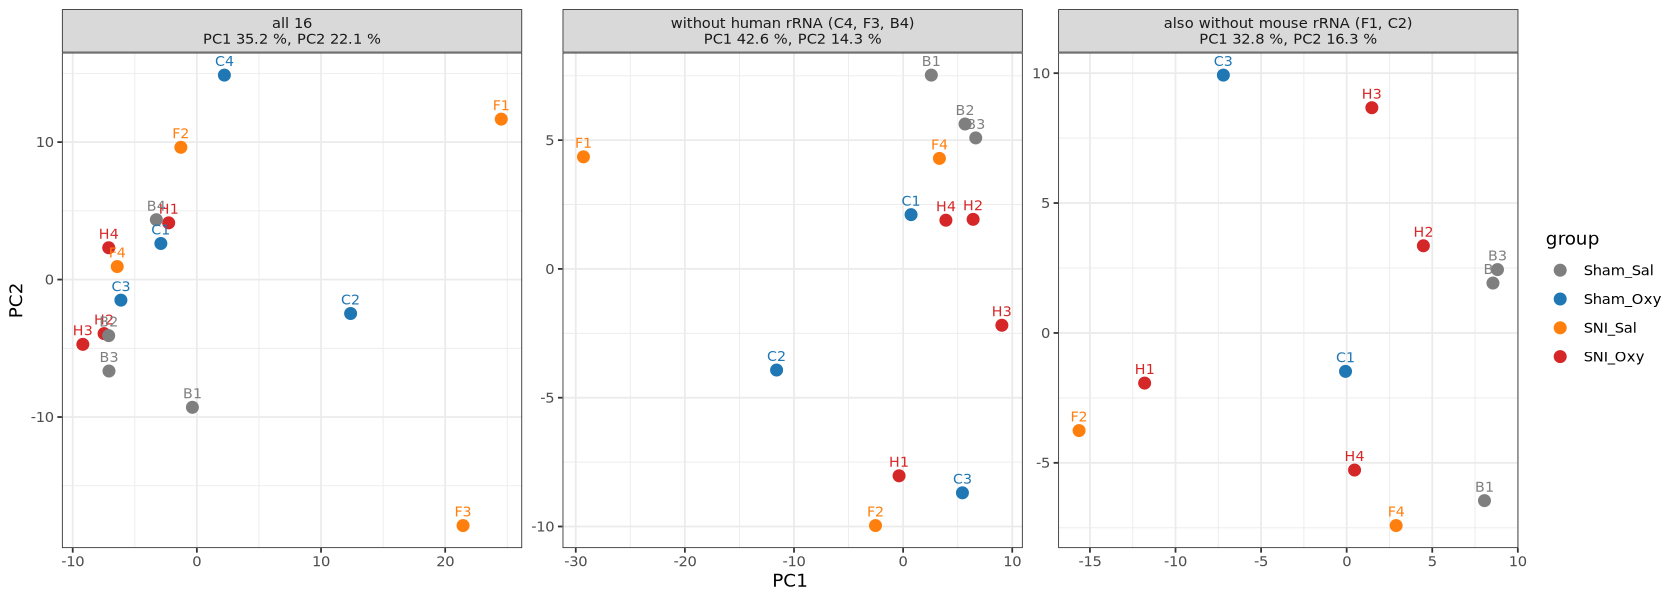

In [ ]:
import os
import subprocess
from IPython.display import Image

# DESeq2 is not in the cwbd env, so the R code runs in the Bioconductor container nf-core already pulled
DESEQ2_IMAGE = "community.wave.seqera.io/library/bioconductor-deseq2_bioconductor-limma:b56a0c9ddc3e87e1"

def run_r(code):
    cmd = ["docker", "run", "-i", "--rm", "--user", f"{os.getuid()}:{os.getgid()}",
           "-v", f"{os.getcwd()}:/w", "-w", "/w", DESEQ2_IMAGE, "Rscript", "-"]
    p = subprocess.run(cmd, input=code, text=True, capture_output=True)
    print(p.stdout if p.returncode == 0 else p.stderr)

R_SETUP = """
suppressPackageStartupMessages({ library(DESeq2); library(ggplot2); library(matrixStats) })
cts <- read.delim("rnaseq_out_allsamples/star_salmon/salmon.merged.gene_counts.tsv", check.names = FALSE)
genes <- cts[, 1:2]
cts <- round(as.matrix(cts[, -(1:2)])); rownames(cts) <- genes$gene_id
cd <- read.csv("samples_allsamples.csv", row.names = 1)
cd$surgery   <- factor(cd$surgery,   levels = c("Sham", "SNI"))
cd$treatment <- factor(cd$treatment, levels = c("Sal", "Oxy"))
cd$group     <- factor(cd$group, levels = c("Sham_Sal", "Sham_Oxy", "SNI_Sal", "SNI_Oxy"))
cts <- cts[, rownames(cd)]
sets <- list(
  "all 16"                                = rownames(cd),
  "without human rRNA (C4, F3, B4)"       = rownames(cd)[!cd$title %in% c("C4", "F3", "B4")],
  "also without mouse rRNA (F1, C2)"      = rownames(cd)[!cd$title %in% c("C4", "F3", "B4", "F1", "C2")]
)
"""

# PCA on vst counts, top 500 variable genes (same recipe as the nf-core/rnaseq QC PCA)
run_r(R_SETUP + """
pca <- do.call(rbind, lapply(names(sets), function(s) {
  keep <- sets[[s]]
  v <- assay(vst(DESeqDataSetFromMatrix(cts[, keep], cd[keep, ], ~ group), blind = TRUE))
  v <- v[order(rowVars(v), decreasing = TRUE)[1:500], ]
  p <- prcomp(t(v)); ve <- round(100 * p$sdev^2 / sum(p$sdev^2), 1)
  data.frame(set = sprintf("%s\\nPC1 %s %%, PC2 %s %%", s, ve[1], ve[2]),
             PC1 = p$x[, 1], PC2 = p$x[, 2], cd[keep, c("title", "group")])
}))
pca$set <- factor(pca$set, levels = unique(pca$set))
g <- ggplot(pca, aes(PC1, PC2, colour = group)) + geom_point(size = 3) +
  geom_text(aes(label = title), vjust = -0.9, size = 3, show.legend = FALSE) +
  facet_wrap(~ set, scales = "free") + theme_bw() +
  scale_colour_manual(values = c(Sham_Sal = "#7f7f7f", Sham_Oxy = "#1f77b4", SNI_Sal = "#ff7f0e", SNI_Oxy = "#d62728"))
ggsave("figures/pca_allsamples.png", g, width = 14, height = 5, dpi = 120)
""")
Image("figures/pca_allsamples.png")


### Differential expression compared with the paper

Design `~ group` for the paper's three comparisons (each against Sham_Sal), plus `~ surgery * treatment` for the SNI:Oxy interaction. Genes with at least 10 counts in at least 3 samples. Cutoff as in the paper: nominal p < 0.05 and |log2FC| > 0.5. The FDR hits (padj < 0.05) are in brackets.

| Comparison | all 16 | without C4 (SRR23195506), F3 (SRR23195510), B4 (SRR23195507) | paper |
|---|---|---|---|
| SNI_Sal vs Sham_Sal | 1071 (108) | 1716 (559) | 1457 |
| Sham_Oxy vs Sham_Sal | 1194 (75) | 1469 (480) | 2609 |
| SNI_Oxy vs Sham_Sal | 564 (4) | 1091 (279) | 1012 |
| SNI_Oxy vs SNI_Sal | 561 (9) | 521 (2) | |
| interaction SNI:Oxy | 1571 (97) | 1946 (238) | |

- **Removing the three contaminated samples raises almost every count despite fewer replicates.** The FDR hits jump from 4 to 108 up to 279 to 559. Those samples added so much noise that they hid the effects.
- **The clean set is close to the paper** for SNI_Sal (1716 vs 1457) and SNI_Oxy vs Sham_Sal (1091 vs 1012). Sham_Oxy stays lower (1469 vs 2609), plausibly because that group lost C4 and still contains C2 (mouse rRNA). Other differences add to this: the paper used HISAT2 and HTSeq on mm10 with Ensembl 90, this run STAR and Salmon on GRCm38, and the paper does not say whether it excluded samples.
- **The nominal cutoff is generous.** With about 16,000 genes tested, roughly 800 pass p < 0.05 by chance before the fold change filter. The FDR numbers are the more reliable ones.
- **SNI_Oxy vs SNI_Sal barely has FDR hits.** Its top genes include Rn18s-rs5 and mitochondrial genes, so it mostly reflects rRNA and quality differences (F1, SRR23195518, is in SNI_Sal).
- **Caveat:** Sham_Sal, the reference in all three paper comparisons, is also the cleanest group: B2 (SRR23195515) and B3 (SRR23195512) are below 1 % human reads, while F2 (SRR23195513), B1 (SRR23195520) and C1 (SRR23195519) still carry 10 to 17 %. The check in the last cell shows that DEGs correlate a bit more with the human read share than random genes do (median |rho| about 0.41 vs 0.28), but they are not enriched for strong correlations (|rho| > 0.6). Part of the gain could still be contamination. Removing human reads before quantification (BBSplit or a combined mouse and human index) would settle it.

![DEG counts](figures/deg_counts_vs_paper.png)

*DEGs at the paper's cutoff for all 16 samples, without the three human rRNA samples, and as reported by Mitsi et al. 2023.*

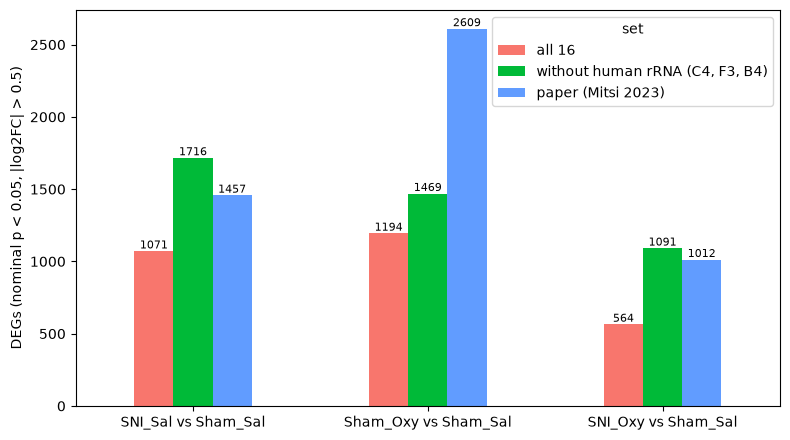

,set,comparison,tested,paper_cutoff,up,down,padj_0.05,top_genes
0,all 16,SNI_Sal vs Sham_Sal,16345,1071,719,352,108,"Lrtm1, RP23-211E12.6, AC099934.1, Gm2026, RP24..."
1,all 16,Sham_Oxy vs Sham_Sal,16345,1194,863,331,75,"Lrtm1, RP23-211E12.6, Khdrbs2, Sst, Adcyap1, G..."
2,all 16,SNI_Oxy vs Sham_Sal,16345,564,339,225,4,"AC099934.1, Gm2026, Lrtm1, Khdrbs2, Hdx, RP23-..."
3,all 16,SNI_Oxy vs SNI_Sal,16345,561,177,384,9,"Gm21698, Rn18s-rs5, Gm26981, Lars2, Top2a, Cck"
4,all 16,interaction SNI:Oxy,16345,1571,558,1013,97,"Lrtm1, Mfsd4, Lars2, Adcyap1, Rn18s-rs5, RP23-..."
5,"without human rRNA (C4, F3, B4)",SNI_Sal vs Sham_Sal,16217,1716,1335,381,559,"RP24-296L6.2, C230004F18Rik, Eif5b, RP23-140B2..."
6,"without human rRNA (C4, F3, B4)",Sham_Oxy vs Sham_Sal,16217,1469,1157,312,480,"C230004F18Rik, Gm38286, RP23-140B23.1, RP24-29..."
7,"without human rRNA (C4, F3, B4)",SNI_Oxy vs Sham_Sal,16217,1091,890,201,279,"C230004F18Rik, AC099934.1, RP24-296L6.2, Hdx, ..."
8,"without human rRNA (C4, F3, B4)",SNI_Oxy vs SNI_Sal,16217,521,171,350,2,"Top2a, mt-Nd6, Cck, mt-Co2, Gm14760, Ppap2b"
9,"without human rRNA (C4, F3, B4)",interaction SNI:Oxy,16217,1946,608,1338,238,"RP23-309G12.1, RP24-296L6.2, Adcyap1, Kcnma1, ..."


In [ ]:
# DESeq2 on all 16 and on the 13 clean samples. The paper's three comparisons are each against Sham_Sal,
# with nominal p < 0.05 and |log2FC| > 0.5. SNI_Oxy vs SNI_Sal and the SNI:Oxy interaction are added.
run_r(R_SETUP + """
out <- "results/deseq2_allsamples"; dir.create(out, recursive = TRUE, showWarnings = FALSE)
contrasts <- list(
  "SNI_Sal vs Sham_Sal"  = c("group", "SNI_Sal",  "Sham_Sal"),
  "Sham_Oxy vs Sham_Sal" = c("group", "Sham_Oxy", "Sham_Sal"),
  "SNI_Oxy vs Sham_Sal"  = c("group", "SNI_Oxy",  "Sham_Sal"),
  "SNI_Oxy vs SNI_Sal"   = c("group", "SNI_Oxy",  "SNI_Sal"))
summ <- do.call(rbind, lapply(names(sets)[1:2], function(s) {
  keep <- sets[[s]]
  dds <- DESeqDataSetFromMatrix(cts[, keep], cd[keep, ], ~ group)
  dds <- DESeq(dds[rowSums(counts(dds) >= 10) >= 3, ], quiet = TRUE)
  ddi <- DESeqDataSetFromMatrix(cts[rownames(dds), keep], cd[keep, ], ~ surgery * treatment)
  ddi <- DESeq(ddi, quiet = TRUE)
  res <- c(lapply(contrasts, function(k) results(dds, contrast = k)),
           list("interaction SNI:Oxy" = results(ddi, name = "surgerySNI.treatmentOxy")))
  do.call(rbind, lapply(names(res), function(n) {
    r <- as.data.frame(res[[n]]); r$gene_name <- genes$gene_name[match(rownames(r), genes$gene_id)]
    r <- r[order(r$pvalue), ]
    write.table(r, sprintf("%s/%s__%s.tsv", out, gsub("[^A-Za-z0-9]+", "_", s), gsub("[^A-Za-z0-9]+", "_", n)),
                sep = "\t", quote = FALSE)
    hit <- !is.na(r$pvalue) & r$pvalue < 0.05 & abs(r$log2FoldChange) > 0.5
    data.frame(set = s, comparison = n, tested = sum(!is.na(r$pvalue)), paper_cutoff = sum(hit),
               up = sum(hit & r$log2FoldChange > 0), down = sum(hit & r$log2FoldChange < 0),
               padj_0.05 = sum(!is.na(r$padj) & r$padj < 0.05),
               top_genes = paste(head(r$gene_name, 6), collapse = ", "))
  }))
}))
write.table(summ, file.path(out, "deg_summary.tsv"), sep = "\t", quote = FALSE, row.names = FALSE)
""")

import matplotlib.pyplot as plt

summ = pd.read_csv("results/deseq2_allsamples/deg_summary.tsv", sep="\t")
paper = pd.Series({"SNI_Sal vs Sham_Sal": 1457, "Sham_Oxy vs Sham_Sal": 2609, "SNI_Oxy vs Sham_Sal": 1012})
bars = summ.pivot(index="comparison", columns="set", values="paper_cutoff").loc[paper.index]
bars["paper (Mitsi 2023)"] = paper
ax = bars.plot.bar(figsize=(8, 4.5), rot=0, color=["#f8766d", "#00ba38", "#619cff"])
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
ax.set_xlabel(""); ax.set_ylabel("DEGs (nominal p < 0.05, |log2FC| > 0.5)")
plt.tight_layout(); plt.savefig("figures/deg_counts_vs_paper.png", dpi=120); plt.show()
summ


In [ ]:
import numpy as np
from scipy.stats import spearmanr

# Do the clean set DEGs track the leftover human read share? Compare with random tested genes.
clean = qc[~qc.title.isin(["C4", "F3", "B4"])]
counts = pd.read_csv("rnaseq_out_allsamples/star_salmon/salmon.merged.gene_counts.tsv", sep="\t", index_col=0)
counts = counts[clean.index]
log_counts = np.log(counts.replace(0, np.nan))
size_factors = np.exp(log_counts.sub(log_counts.mean(axis=1), axis=0).dropna().median())  # DESeq2 median of ratios
norm = np.log2(counts / size_factors + 1)

def abs_rho(genes):
    return np.array([abs(spearmanr(norm.loc[g], clean["human_rDNA_%"])[0]) for g in genes])

rows = []
for comp in ["SNI_Sal_vs_Sham_Sal", "Sham_Oxy_vs_Sham_Sal", "SNI_Oxy_vs_Sham_Sal"]:
    r = pd.read_csv(f"results/deseq2_allsamples/without_human_rRNA_C4_F3_B4___{comp}.tsv", sep="\t", index_col=0)
    sig = abs_rho(r.index[r.padj < 0.05])
    rnd = abs_rho(r.dropna(subset=["padj"]).sample(500, random_state=0).index)
    rows.append({"comparison": comp, "n_padj_0.05": len(sig),
                 "median_|rho|_DEGs": np.nanmedian(sig), "median_|rho|_random": np.nanmedian(rnd),
                 "|rho|>0.6_DEGs_%": 100 * np.nanmean(sig > 0.6), "|rho|>0.6_random_%": 100 * np.nanmean(rnd > 0.6)})
pd.DataFrame(rows).round(2)


,comparison,n_padj_0.05,median_|rho|_DEGs,median_|rho|_random,|rho|>0.6_DEGs_%,|rho|>0.6_random_%
0,SNI_Sal_vs_Sham_Sal,559,0.41,0.27,8.41,8.0
1,Sham_Oxy_vs_Sham_Sal,480,0.42,0.28,7.29,11.0
2,SNI_Oxy_vs_Sham_Sal,279,0.40,0.30,3.23,7.0
